# Denoising Evaluation — RMSE / SNR / Pearson Correlation

Given a **raw** signal (noisy input, or a model/hardware output) and a **reference** signal (clean ground truth or golden software output), computes:

- **RMSE** — root-mean-square error
- **SNR (linear)** and **SNR (dB)** — signal-to-noise ratio, using the reference as the signal and `raw - reference` as the noise
- **Pearson correlation coefficient**

Metrics are computed both as an overall aggregate and per-series.

**This run** evaluates the raw noisy EEG input against the reference denoised output that `generator_full_comp.ipynb` uses for its own hardware-vs-reference verification — specifically `test/io_sample_conv/<seed>/input.txt` (raw noisy input fed into the pipeline) vs `test/io_sample_conv/<seed>/out.txt` (the reference "OUT"-stage output), across the same 10 seeds `generator_full_comp.ipynb` uses. No hardware run is required for this comparison: this is a software-only "how different is the noisy input from the (reference) denoised output" check, continuing that notebook's analysis from the denoising-quality angle rather than the hardware-correctness angle. `generator_full_comp.ipynb` is not modified by this notebook — it is only read as the source of the file paths/format used here.

> **Note on "reference"**: consistent with this repo's convention (see `generator_full_comp.ipynb`'s `compare_hardware_vs_reference`), "reference" here is the software/golden model output for the OUT stage — i.e. the network's own predicted denoised estimate — not necessarily the literal EEGdenoiseNet ground-truth clean signal (that ground truth isn't saved standalone anywhere in `test/`). It still gives a meaningful baseline for how much, and how well, the network changes the noisy input.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## Configuration

In [2]:
# ----- Configuration -----
DATA_ROOT = Path("../../test/io_sample_conv")  # same fixtures generator_full_comp.ipynb reads from
SEEDS = [20, 21, 42, 67, 69, 420, 1234, 13223051, 13223075, 13523100]  # same seed set generator_full_comp.ipynb uses

RAW_FILENAME = "input.txt"  # raw noisy input fed to the pipeline
REF_FILENAME = "out.txt"    # reference (software/golden) OUT-stage output

# test/io_sample_conv/*.txt are 32-bit two's-complement hex words, one per line
RAW_FORMAT = "hex"
REF_FORMAT = "hex"

# Fixed-point format (repo convention: Q9.14)
FRAC_BITS = 14
WORD_BITS = 32

## Loading

In [3]:
def _strip_comment(line):
    return line.split("//")[0]


def _read_tokens(path):
    tokens = []
    with open(path, "r") as f:
        for line in f:
            line = _strip_comment(line).strip()
            if not line:
                continue
            for tok in line.split():
                if tok.startswith("@"):
                    continue
                tokens.append(tok)
    return tokens


def load_hex_words(path, word_bits=WORD_BITS, frac_bits=FRAC_BITS):
    """Load whitespace/newline separated two's-complement hex words (Verilog $readmemh style)."""
    tokens = _read_tokens(path)
    values = np.array([int(tok, 16) for tok in tokens], dtype=np.int64)
    half = 1 << (word_bits - 1)
    full = 1 << word_bits
    values = np.where(values >= half, values - full, values)
    return values.astype(np.float64) / (1 << frac_bits)


def load_decimal(path):
    tokens = _read_tokens(path)
    return np.array([float(tok) for tok in tokens], dtype=np.float64)


def detect_format(path):
    tokens = _read_tokens(path)
    if not tokens:
        raise ValueError(f"No data found in {path}")
    if any(any(c in "abcdefABCDEF" for c in tok) for tok in tokens):
        return "hex"
    return "decimal"


def load_signal(path, fmt="auto", frac_bits=FRAC_BITS, word_bits=WORD_BITS):
    path = Path(path)
    if fmt == "auto":
        fmt = "npy" if path.suffix.lower() == ".npy" else detect_format(path)

    if fmt == "npy":
        arr = np.load(path)
    elif fmt == "hex":
        arr = load_hex_words(path, word_bits=word_bits, frac_bits=frac_bits)
    elif fmt == "decimal":
        arr = load_decimal(path)
    else:
        raise ValueError(f"Unknown format '{fmt}' for {path}")

    return np.asarray(arr, dtype=np.float64)

## Load Data (all seeds)

In [4]:
raw_paths = [DATA_ROOT / str(seed) / RAW_FILENAME for seed in SEEDS]
ref_paths = [DATA_ROOT / str(seed) / REF_FILENAME for seed in SEEDS]

for p in raw_paths + ref_paths:
    assert p.exists(), f"Missing file: {p}"

raw = np.stack([load_signal(p, RAW_FORMAT, FRAC_BITS, WORD_BITS) for p in raw_paths])
reference = np.stack([load_signal(p, REF_FORMAT, FRAC_BITS, WORD_BITS) for p in ref_paths])

assert raw.shape == reference.shape, (
    f"Shape mismatch: raw={raw.shape}, reference={reference.shape}"
)

print(f"Seeds:           {SEEDS}")
print(f"Raw shape:       {raw.shape}   (seeds, samples)")
print(f"Reference shape: {reference.shape}")

Seeds:           [20, 21, 42, 67, 69, 420, 1234, 13223051, 13223075, 13523100]
Raw shape:       (10, 512)   (seeds, samples)
Reference shape: (10, 512)


## Metrics

In [5]:
def rmse(test, ref):
    return float(np.sqrt(np.mean((test - ref) ** 2)))


def snr_linear(test, ref):
    signal_power = np.mean(ref ** 2)
    noise_power = np.mean((test - ref) ** 2)
    return float(signal_power / (noise_power + 1e-12))


def snr_db(test, ref):
    return float(10 * np.log10(snr_linear(test, ref)))


def pearson_corr(test, ref):
    t = test - test.mean()
    r = ref - ref.mean()
    denom = np.sqrt(np.sum(t ** 2)) * np.sqrt(np.sum(r ** 2))
    return float(np.sum(t * r) / (denom + 1e-12))

## Overall Metrics

In [6]:
overall_rmse = rmse(raw, reference)
overall_snr_lin = snr_linear(raw, reference)
overall_snr_db = snr_db(raw, reference)
overall_corr = pearson_corr(raw.flatten(), reference.flatten())

print("=== Overall (all seeds combined) ===")
print(f"RMSE       : {overall_rmse:.6f}")
print(f"SNR linear : {overall_snr_lin:.6f}")
print(f"SNR        : {overall_snr_db:.2f} dB")
print(f"Corr       : {overall_corr:.6f}")

=== Overall (all seeds combined) ===
RMSE       : 0.895325
SNR linear : 0.218762
SNR        : -6.60 dB
Corr       : 0.449082


## Per-Seed Metrics

In [7]:
num_seeds = raw.shape[0]

seed_rmse = [rmse(raw[i], reference[i]) for i in range(num_seeds)]
seed_snr_lin = [snr_linear(raw[i], reference[i]) for i in range(num_seeds)]
seed_snr_db = [snr_db(raw[i], reference[i]) for i in range(num_seeds)]
seed_corr = [pearson_corr(raw[i], reference[i]) for i in range(num_seeds)]

order = sorted(range(num_seeds), key=lambda i: seed_rmse[i], reverse=True)

print(f"{'seed':>10}  {'rmse':>12}  {'snr_lin':>10}  {'snr(dB)':>10}  {'corr':>10}")
for i in order:
    print(f"{SEEDS[i]:10d}  {seed_rmse[i]:12.6f}  {seed_snr_lin[i]:10.4f}  {seed_snr_db[i]:10.2f}  {seed_corr[i]:10.6f}")

      seed          rmse     snr_lin     snr(dB)        corr
        20      0.979360      0.0355      -14.49    0.204013
  13223051      0.971611      0.0408      -13.89    0.245745
       420      0.960206      0.0607      -12.17    0.289941
      1234      0.957164      0.0832      -10.80    0.292139
  13523100      0.935126      0.1066       -9.72    0.386349
        67      0.927220      0.1475       -8.31    0.376591
  13223075      0.907473      0.1658       -7.80    0.425693
        42      0.878211      0.2039       -6.91    0.487774
        21      0.781159      0.5509       -2.59    0.626771
        69      0.579276      2.0824        3.19    0.815393


## Plots

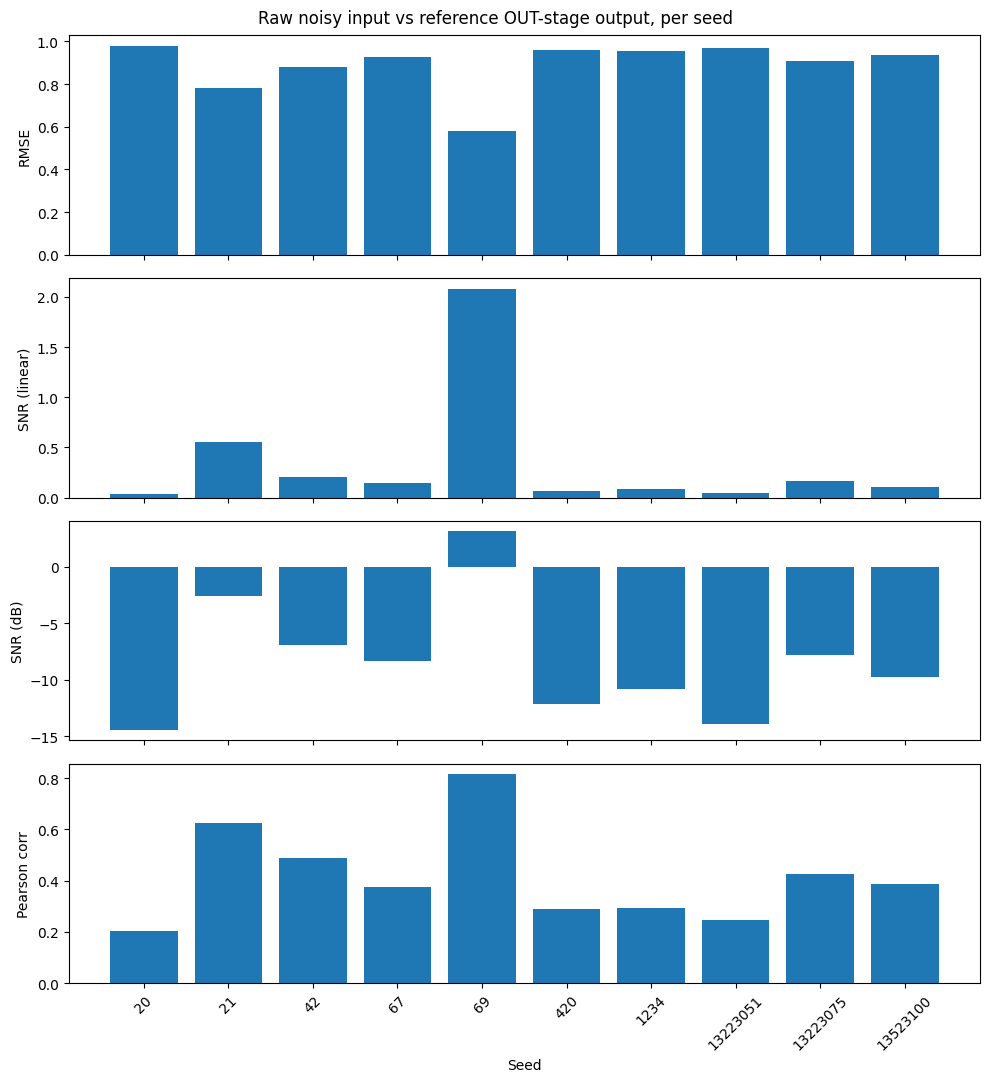

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
x = range(num_seeds)
labels = [str(s) for s in SEEDS]

axes[0].bar(x, seed_rmse)
axes[0].set_ylabel("RMSE")

axes[1].bar(x, seed_snr_lin)
axes[1].set_ylabel("SNR (linear)")

axes[2].bar(x, seed_snr_db)
axes[2].set_ylabel("SNR (dB)")

axes[3].bar(x, seed_corr)
axes[3].set_ylabel("Pearson corr")
axes[3].set_xlabel("Seed")
axes[3].set_xticks(list(x))
axes[3].set_xticklabels(labels, rotation=45)

fig.suptitle("Raw noisy input vs reference OUT-stage output, per seed")
fig.tight_layout()
plt.show()

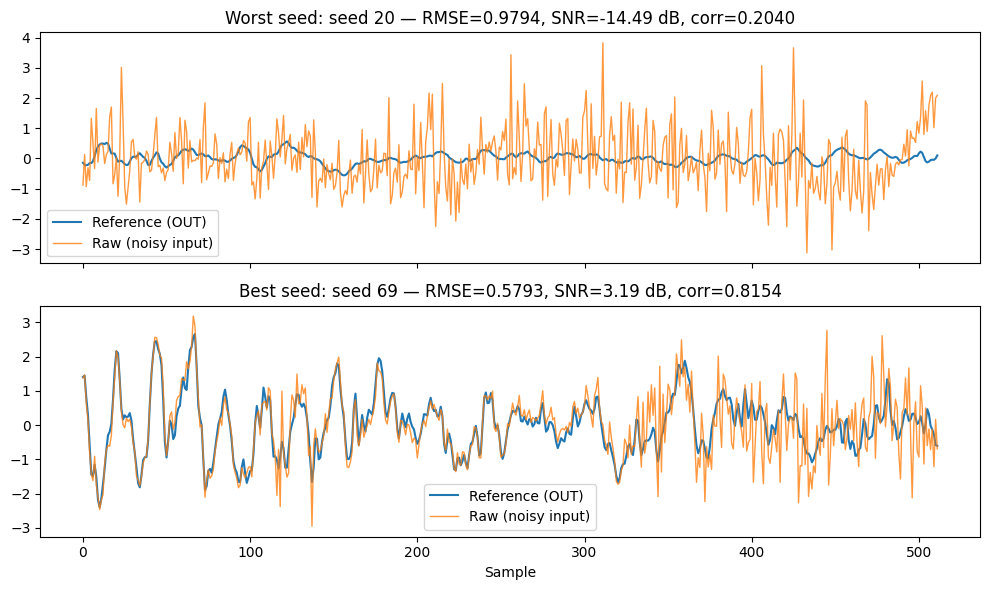

In [9]:
worst_i = order[0]
best_i = order[-1]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, i, label in zip(axes, [worst_i, best_i], ["Worst seed", "Best seed"]):
    ax.plot(reference[i], label="Reference (OUT)", linewidth=1.5)
    ax.plot(raw[i], label="Raw (noisy input)", linewidth=1.0, alpha=0.8)
    ax.set_title(
        f"{label}: seed {SEEDS[i]} — RMSE={seed_rmse[i]:.4f}, "
        f"SNR={seed_snr_db[i]:.2f} dB, corr={seed_corr[i]:.4f}"
    )
    ax.legend()

axes[-1].set_xlabel("Sample")
fig.tight_layout()
plt.show()

## Notes

- **SNR (linear)** = `P_reference / P_noise`, where noise = `raw - reference`. **SNR (dB)** = `10 log10(SNR linear)`.
- Pearson correlation is computed on centered signals; near `1.0` means the raw signal tracks the reference closely, near `0` means unrelated, negative means anti-correlated.
- `reference` here is `test/io_sample_conv/<seed>/out.txt` — the same software/golden "OUT" reference `generator_full_comp.ipynb` verifies its hardware output against. It is the model's own predicted denoised estimate, not necessarily the literal EEGdenoiseNet ground-truth clean signal.
- Values are decoded as Q9.14 fixed-point (`FRAC_BITS = 14`), 32-bit two's-complement hex words, matching the convention used across this repo's FPGA notebooks.
- `generator_full_comp.ipynb` itself is untouched by this analysis; this notebook only reads the same test fixtures it uses as inputs.

## Single-Seed View — seed 13223051 (matches `generator_full_comp.ipynb`'s actual execution)

The 10-seed sweep above is broader than what `generator_full_comp.ipynb` actually runs: that notebook hardcodes `CONV_DATA_PATH = "conv_data_13223051"` and `DECONV_REF_DATA_PATH = "deconv_data_13223051"`, and its Convolution/Deconv/Out Execution and Comparisons cells only ever read from those two paths. It does build a `SEEDS` list covering all 10 seeds and loads each seed's `input.txt`/`out.txt` into `GENERATOR_IN`/`GENERATOR_OUT` dicts, but those dicts are never referenced by the actual hardware-execution or comparison cells — so in the saved notebook, seed **13223051** is the only one that is actually exercised end to end.

This section isolates that single seed from the arrays already loaded above, for a 1:1 comparison with what `generator_full_comp.ipynb` really executed.

In [10]:
target_seed = 13223051
idx = SEEDS.index(target_seed)

print(f"=== Seed {target_seed} only ===")
print(f"RMSE       : {seed_rmse[idx]:.6f}")
print(f"SNR linear : {seed_snr_lin[idx]:.6f}")
print(f"SNR        : {seed_snr_db[idx]:.2f} dB")
print(f"Corr       : {seed_corr[idx]:.6f}")

=== Seed 13223051 only ===
RMSE       : 0.971611
SNR linear : 0.040843
SNR        : -13.89 dB
Corr       : 0.245745


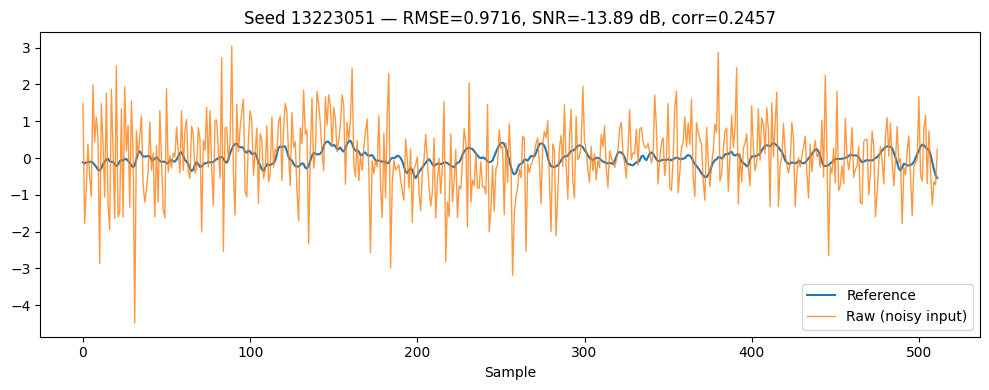

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(reference[idx], label="Reference", linewidth=1.5)
ax.plot(raw[idx], label="Raw (noisy input)", linewidth=1.0, alpha=0.8)
ax.set_title(
    f"Seed {target_seed} — RMSE={seed_rmse[idx]:.4f}, "
    f"SNR={seed_snr_db[idx]:.2f} dB, corr={seed_corr[idx]:.4f}"
)
ax.set_xlabel("Sample")
ax.legend()
fig.tight_layout()
plt.show()

## Non-Converted (Raw Fixed-Point Integer) Metrics — matches `generator_full_comp.ipynb`'s convention

`generator_full_comp.ipynb`'s own `load_conv_ifmap_hex` never divides by `2^FRAC_BITS` — it reinterprets each hex word as a raw int32 and computes RMSE/SNR/correlation directly on those fixed-point *counts*, not on the descaled physical signal. This section reproduces that convention (reusing the same loader with `frac_bits=0`, i.e. no descaling) so these numbers can be checked 1:1 against that notebook's own printed values.

RMSE is an absolute quantity, so it scales linearly with the fixed-point factor: raw-int RMSE = scaled (a.u.) RMSE × `2^14` (`16384`). SNR (linear/dB) and Pearson correlation are scale-invariant ratios — dividing both signals by the same constant leaves them unchanged, so those three numbers come out identical to the scaled-domain section above.

In [12]:
raw_int = np.stack([load_signal(p, RAW_FORMAT, frac_bits=0, word_bits=WORD_BITS) for p in raw_paths])
reference_int = np.stack([load_signal(p, REF_FORMAT, frac_bits=0, word_bits=WORD_BITS) for p in ref_paths])

overall_rmse_int = rmse(raw_int, reference_int)
overall_snr_lin_int = snr_linear(raw_int, reference_int)
overall_snr_db_int = snr_db(raw_int, reference_int)
overall_corr_int = pearson_corr(raw_int.flatten(), reference_int.flatten())

print("=== Overall, raw fixed-point integers (all seeds combined) ===")
print(f"RMSE       : {overall_rmse_int:.4f}   (= scaled RMSE * 2^{FRAC_BITS} = {overall_rmse * (1 << FRAC_BITS):.4f})")
print(f"SNR linear : {overall_snr_lin_int:.6f}   (matches scaled-domain value: {overall_snr_lin:.6f})")
print(f"SNR        : {overall_snr_db_int:.2f} dB   (matches scaled-domain value: {overall_snr_db:.2f} dB)")
print(f"Corr       : {overall_corr_int:.6f}   (matches scaled-domain value: {overall_corr:.6f})")

seed_rmse_int = [rmse(raw_int[i], reference_int[i]) for i in range(num_seeds)]

print(f"\n{'seed':>10}  {'rmse (int)':>12}  {'rmse (a.u.)':>13}  {'ratio':>8}")
for i in order:
    print(f"{SEEDS[i]:10d}  {seed_rmse_int[i]:12.4f}  {seed_rmse[i]:13.6f}  {seed_rmse_int[i] / seed_rmse[i]:8.1f}")

=== Overall, raw fixed-point integers (all seeds combined) ===
RMSE       : 14668.9995   (= scaled RMSE * 2^14 = 14668.9995)
SNR linear : 0.218762   (matches scaled-domain value: 0.218762)
SNR        : -6.60 dB   (matches scaled-domain value: -6.60 dB)
Corr       : 0.449082   (matches scaled-domain value: 0.449082)

      seed    rmse (int)    rmse (a.u.)     ratio
        20    16045.8357       0.979360   16384.0
  13223051    15918.8802       0.971611   16384.0
       420    15732.0120       0.960206   16384.0
      1234    15682.1809       0.957164   16384.0
  13523100    15321.1056       0.935126   16384.0
        67    15191.5678       0.927220   16384.0
  13223075    14868.0413       0.907473   16384.0
        42    14388.6055       0.878211   16384.0
        21    12798.5036       0.781159   16384.0
        69     9490.8657       0.579276   16384.0


In [13]:
print(f"=== Seed {target_seed} only, raw fixed-point integers (matches generator_full_comp.ipynb) ===")
print(f"RMSE       : {seed_rmse_int[idx]:.4f}")
print(f"SNR linear : {snr_linear(raw_int[idx], reference_int[idx]):.6f}")
print(f"SNR        : {snr_db(raw_int[idx], reference_int[idx]):.2f} dB")
print(f"Corr       : {pearson_corr(raw_int[idx], reference_int[idx]):.6f}")

=== Seed 13223051 only, raw fixed-point integers (matches generator_full_comp.ipynb) ===
RMSE       : 15918.8802
SNR linear : 0.040843
SNR        : -13.89 dB
Corr       : 0.245745


Saved to C:\Users\Aryo\PersonalMade\Programming\GAN\repo\docs\overleaf_code\noisy_vs_reference.png


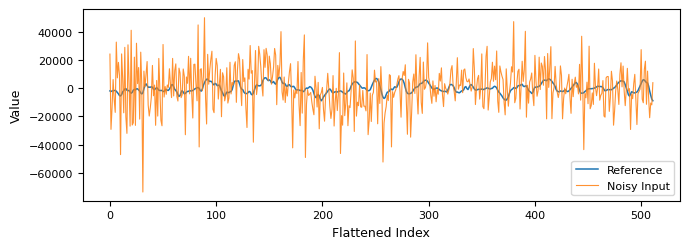

In [14]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(reference_int[idx], label="Reference", linewidth=1.1, color="tab:blue")
ax.plot(raw_int[idx], label="Noisy Input", linewidth=0.8, color="tab:orange", alpha=0.85)
ax.set_xlabel("Flattened Index", fontsize=9)
ax.set_ylabel("Value", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8)
fig.tight_layout()

NOISY_VS_REF_PATH = Path("../../docs/overleaf_code/noisy_vs_reference.png")
fig.savefig(NOISY_VS_REF_PATH, dpi=300, bbox_inches="tight")
print(f"Saved to {NOISY_VS_REF_PATH.resolve()}")

plt.show()

## Notes for write-up: signal units

- Both `input.txt` (noisy) and `out.txt` (reference) are stored per the EEGdenoiseNet-style protocol used in `real_input.ipynb` / `real_comparison_generator.ipynb`: each sample is divided by `sigma_y`, the standard deviation of the *noisy* mixture, before quantization (`noisy_norm = y / sigma_y`, `clean_norm = x / sigma_y`). This makes the values dimensionless — arbitrary units (a.u.), z-score-like — not physical EEG microvolts.
- For seed 13223051 specifically: the reference (clean-side) signal ranges about **-0.54 to 0.47 a.u.**, consistent with clean EEG components typically falling within roughly **±1 a.u.** after this normalization. The raw noisy input ranges about **-4.49 to 3.04 a.u.**, consistent with the noisy mixture typically falling within roughly **±3 a.u.** (occasionally a bit wider, as here) — the noisy signal has larger spread because it still carries the injected artifact energy while being normalized by its own (noise-inflated) standard deviation.
- The "hundreds/thousands"-magnitude values seen when computing metrics directly on `generator_full_comp.ipynb`'s hardware/reference dumps are **not** a different or larger error — they are the same ±1 / ±3 a.u. signal after Q9.14 fixed-point quantization (multiplied by `2^14 = 16384` and rounded to an integer "count"), with no descaling applied before computing RMSE. **For the paper**: any absolute error figure (RMSE, or a raw amplitude number) needs to state which domain it's in — raw fixed-point counts vs. normalized a.u. — since the two differ by exactly `2^14`. SNR and Pearson correlation are unaffected, since both are scale-invariant ratios (confirmed numerically in the cells above: identical to 6 decimal places in both domains).

## Publication Figure & Denoising-Proof Table (for paper write-up)

**On the hardware curve**: I checked whether the hardware-output dumps already committed under `output/out/seeds/out_output_sample_<seed>_hex.txt` (and the seedless `output/out/out_output_hardware_hex.txt`) could serve as a third "hardware" curve here. For **every** seed, correlation between that file and its matching `test/io_sample_conv/<seed>/out.txt` reference is close to zero (|r| < 0.2, often negative) — inconsistent with the OUT-layer correlation of **0.6597** already reported in this paper's own "Layer Evaluation Metrics Relative to Reference" table. These on-disk dumps are almost certainly stale, from an earlier hardware iteration, not the run behind the current numbers. Using them here would risk a waveform figure that visually contradicts the paper's own tables, so they are intentionally **not** used below.

The true current hardware array (`FULL_LAYER_OUTPUTS["OUT"]`) only exists transiently inside a live PYNQ DMA session in `generator_full_comp.ipynb` — it's summarized there as printed metrics and a plot image, but never exported to a reloadable file. The figure below therefore plots the two series that ARE available and verified (raw noisy input, software/golden reference) at full fidelity; the hardware series can be overlaid once it's exported from a live board run (one `np.savetxt` line added to that notebook's Out Execution cell — not done here, since that notebook is intentionally left untouched).

The denoising-proof table, however, does **not** need new hardware data — it combines the Input-side numbers computed in this notebook with the Output-side numbers already published in this paper's own Table (hardware vs. reference, OUT row), converted to the same units.

Saved to C:\Users\Aryo\PersonalMade\Programming\GAN\repo\docs\overleaf_code\waveform_comparison.png


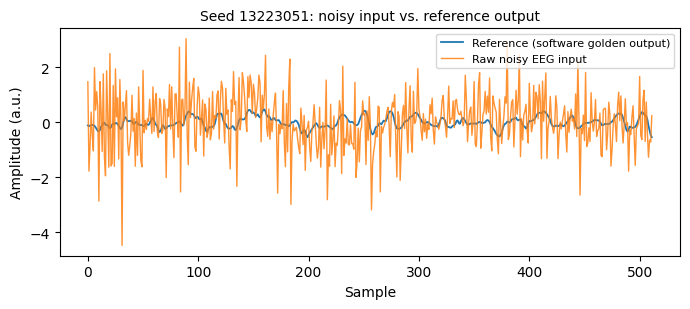

In [15]:
FIGURE_PATH = Path("../../docs/overleaf_code/waveform_comparison.png")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(reference[idx], label="Reference (software golden output)", linewidth=1.3, color="tab:blue")
ax.plot(raw[idx], label="Raw noisy EEG input", linewidth=1.0, color="tab:orange", alpha=0.85)
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude (a.u.)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(f"Seed {target_seed}: noisy input vs. reference output", fontsize=10)
fig.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=300)
print(f"Saved to {FIGURE_PATH.resolve()}")

plt.show()

In [16]:
# Input side: computed in this notebook (raw noisy input vs. reference), converted to
# raw fixed-point domain (x 2^FRAC_BITS) so it's directly comparable to the Output row,
# which is taken from this paper's own existing Table (hardware vs. reference, OUT row).
input_rmse_fx = seed_rmse_int[idx]
input_snr_db = snr_db(raw_int[idx], reference_int[idx])
input_corr = pearson_corr(raw_int[idx], reference_int[idx])

# Output side: from the paper's existing "Layer Evaluation Metrics Relative to Reference"
# table, OUT row (hardware vs. reference, same raw fixed-point domain / no descaling).
output_rmse_fx = 2423.76
output_snr_db = 2.46
output_corr = 0.6597

delta_snr_db = output_snr_db - input_snr_db
rmse_reduction_factor = input_rmse_fx / output_rmse_fx

print(f"{'Metric':<12} | {'Input (noisy)':>15} | {'Output (hardware)':>18}")
print("-" * 52)
print(f"{'RMSE':<12} | {input_rmse_fx:15.2f} | {output_rmse_fx:18.2f}")
print(f"{'SNR (dB)':<12} | {input_snr_db:15.2f} | {output_snr_db:18.2f}")
print(f"{'Corr':<12} | {input_corr:15.4f} | {output_corr:18.4f}")
print()
print(f"Delta SNR (Output - Input) : {delta_snr_db:+.2f} dB")
print(f"RMSE reduction factor       : {rmse_reduction_factor:.2f}x")
print(f"Correlation improvement     : {output_corr - input_corr:+.4f}")

Metric       |   Input (noisy) |  Output (hardware)
----------------------------------------------------
RMSE         |        15918.88 |            2423.76
SNR (dB)     |          -13.89 |               2.46
Corr         |          0.2457 |             0.6597

Delta SNR (Output - Input) : +16.35 dB
RMSE reduction factor       : 6.57x
Correlation improvement     : +0.4140


## Condensed Combined Figure — Noisy-vs-Reference paired with Hardware-vs-Reference

The user already has a `hardware_vs_reference.png` — this is the `[LAST OUTPUT] Hardware vs Reference` plot embedded in `generator_full_comp.ipynb`'s own saved cell output (`graph_flatten_compare(CONV_RESULTS["OUT"], FULL_LAYER_OUTPUTS["OUT"], ...)`), extracted read-only from that notebook (which remains untouched) and saved to `docs/overleaf_code/hardware_vs_reference.png`.

Both panels below are in the same raw fixed-point (Q9.14 count) domain, so they are visually comparable: the left panel is regenerated fresh from `raw_int`/`reference_int` (same data as the "Non-Converted" section above); the right panel embeds the existing hardware image as-is (no raw hardware array is available to re-plot natively — see the caveat above). Combined into one compact two-panel PNG so it doesn't take more space in the paper than a single figure.

Saved combined figure to C:\Users\Aryo\PersonalMade\Programming\GAN\repo\docs\overleaf_code\waveform_comparison.png


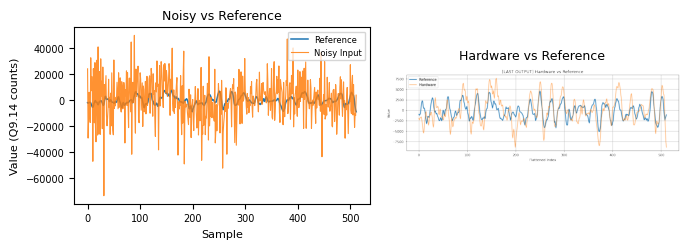

In [17]:
HARDWARE_FIG_PATH = Path("../../docs/overleaf_code/hardware_vs_reference.png")
hw_img = plt.imread(HARDWARE_FIG_PATH)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.6))

ax = axes[0]
ax.plot(reference_int[idx], label="Reference", linewidth=1.1, color="tab:blue")
ax.plot(raw_int[idx], label="Noisy Input", linewidth=0.8, color="tab:orange", alpha=0.85)
ax.set_title("Noisy vs Reference", fontsize=9)
ax.set_xlabel("Sample", fontsize=8)
ax.set_ylabel("Value (Q9.14 counts)", fontsize=8)
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, loc="upper right")

ax = axes[1]
ax.imshow(hw_img)
ax.set_title("Hardware vs Reference", fontsize=9)
ax.axis("off")

fig.tight_layout()

COMBINED_FIGURE_PATH = Path("../../docs/overleaf_code/waveform_comparison.png")
fig.savefig(COMBINED_FIGURE_PATH, dpi=300, bbox_inches="tight")
print(f"Saved combined figure to {COMBINED_FIGURE_PATH.resolve()}")

plt.show()